# 🛩️ SentinelIQ — Notebook 01: Data Exploration

> **NASA C-MAPSS Turbofan Engine Degradation Dataset**

This notebook provides a comprehensive exploratory data analysis (EDA) of the NASA Commercial Modular Aero-Propulsion System Simulation (C-MAPSS) dataset used by SentinelIQ for Remaining Useful Life (RUL) prediction.

---

## Dataset Overview

| Dataset | Training Units | Test Units | Operating Conditions | Fault Modes |
|---------|---------------|------------|---------------------|-------------|
| FD001   | 100           | 100        | 1                   | 1           |
| FD002   | 260           | 259        | 6                   | 1           |
| FD003   | 100           | 100        | 1                   | 2           |
| FD004   | 248           | 249        | 6                   | 2           |

**Columns per file:**
- `unit_id` — engine unit number
- `cycle` — operational cycle (time)
- `op_setting_1/2/3` — operational settings (altitude, throttle, etc.)
- `sensor_1` … `sensor_21` — 21 physical sensor measurements

**Reference:** A. Saxena et al., "Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation," 2008 PHM.

In [1]:
# ── Environment setup ──────────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

# Ensure repo root is on the path so `src` is importable from notebooks/
REPO_ROOT = Path(os.getcwd()).parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Repo root: /media/ibadat/NewVolume/DATA SCIENCE/ML/DATASCIENCE PROJECTS/SentinalIQ_NASA_RUL-CMPASS_SYSTEM/sentinel-iq-cmpass-nasa-rul-prediction
Python: 3.11.15


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from src.config import config
from src.data_loader import CMAPSSLoader

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)  # Suppress verbose INFO in notebook

# Plotting style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})
sns.set_palette('husl')
COLORS = sns.color_palette('husl', 8)

print("✅ Imports loaded")

✅ Imports loaded


## 1. Load FD001 Dataset

In [3]:
# ── Load dataset ───────────────────────────────────────────────────────────────
DATA_DIR = REPO_ROOT / 'data' / 'raw'
loader = CMAPSSLoader(data_dir=DATA_DIR)

try:
    train_df, test_df, rul_df = loader.load_single_dataset('FD001')
    DATA_AVAILABLE = True
    print(f"✅ FD001 loaded")
    print(f"   Train shape : {train_df.shape}")
    print(f"   Test shape  : {test_df.shape}")
    print(f"   RUL rows    : {len(rul_df)}")
except FileNotFoundError:
    print("⚠️  NASA data files not found in data/raw/")
    print("   → Download from: https://www.kaggle.com/datasets/behrad3d/nasa-cmaps")
    print("   → Place train_FD001.txt, test_FD001.txt, RUL_FD001.txt in data/raw/")
    print("   → Generating synthetic demo data for exploration...")
    DATA_AVAILABLE = False

    # Synthetic stand-in (same schema as real data)
    np.random.seed(42)
    n_units, max_cycles = 100, 200
    rows = []
    for uid in range(1, n_units + 1):
        life = np.random.randint(100, max_cycles)
        for c in range(1, life + 1):
            row = [uid, c] + [0.0] * 3 + np.random.randn(21).tolist()
            rows.append(row)
    cols = ['unit_id','cycle','op_setting_1','op_setting_2','op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]
    train_df = pd.DataFrame(rows, columns=cols).astype({'unit_id': 'int32', 'cycle': 'int32'})

    test_rows = []
    test_units = 100
    for uid in range(1, test_units + 1):
        life = np.random.randint(50, 150)
        for c in range(1, life + 1):
            row = [uid, c] + [0.0] * 3 + np.random.randn(21).tolist()
            test_rows.append(row)
    test_df = pd.DataFrame(test_rows, columns=cols).astype({'unit_id': 'int32', 'cycle': 'int32'})
    rul_df = pd.DataFrame({'RUL': np.random.randint(0, 80, size=test_units)})
    print(f"\n📊 Synthetic data: train={train_df.shape}, test={test_df.shape}")

✅ FD001 loaded
   Train shape : (20631, 26)
   Test shape  : (13096, 26)
   RUL rows    : 100


## 2. Basic Dataset Statistics

In [4]:
# ── Dataset statistics ─────────────────────────────────────────────────────────
print("=" * 55)
print("TRAINING SET SUMMARY")
print("=" * 55)
print(f"  Total rows       : {len(train_df):,}")
print(f"  Engine units     : {train_df['unit_id'].nunique()}")
print(f"  Columns          : {train_df.shape[1]}")
print(f"  Memory usage     : {train_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Missing values   : {train_df.isnull().sum().sum()}")
print()

# Per-unit life statistics
unit_lives = train_df.groupby('unit_id')['cycle'].max()
print("Engine Life (cycles):")
print(f"  Min    : {unit_lives.min()}")
print(f"  Max    : {unit_lives.max()}")
print(f"  Mean   : {unit_lives.mean():.1f}")
print(f"  Median : {unit_lives.median():.0f}")
print(f"  Std    : {unit_lives.std():.1f}")

TRAINING SET SUMMARY
  Total rows       : 20,631
  Engine units     : 100
  Columns          : 26
  Memory usage     : 2.3 MB
  Missing values   : 0

Engine Life (cycles):
  Min    : 128
  Max    : 362
  Mean   : 206.3
  Median : 199
  Std    : 46.3


In [5]:
# ── Dtypes and sample rows ─────────────────────────────────────────────────────
print("Column dtypes:")
dtype_summary = train_df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"  {dtype}: {count} columns")
print()
train_df.head(3)

Column dtypes:
  float32: 22 columns
  int32: 2 columns
  int64: 2 columns



,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.669983,641.820007,1589.699951,1400.599976,14.62,...,521.659973,2388.020020,8138.620117,8.4195,0.03,392,2388,100.0,39.060001,23.419001
1,1,2,0.0019,-0.0003,100.0,518.669983,642.150024,1591.819946,1403.140015,14.62,...,522.280029,2388.070068,8131.490234,8.4318,0.03,392,2388,100.0,39.000000,23.423599
2,1,3,-0.0043,0.0003,100.0,518.669983,642.349976,1587.989990,1404.199951,14.62,...,522.419983,2388.030029,8133.229980,8.4178,0.03,390,2388,100.0,38.950001,23.344200


## 3. Engine Life Distribution

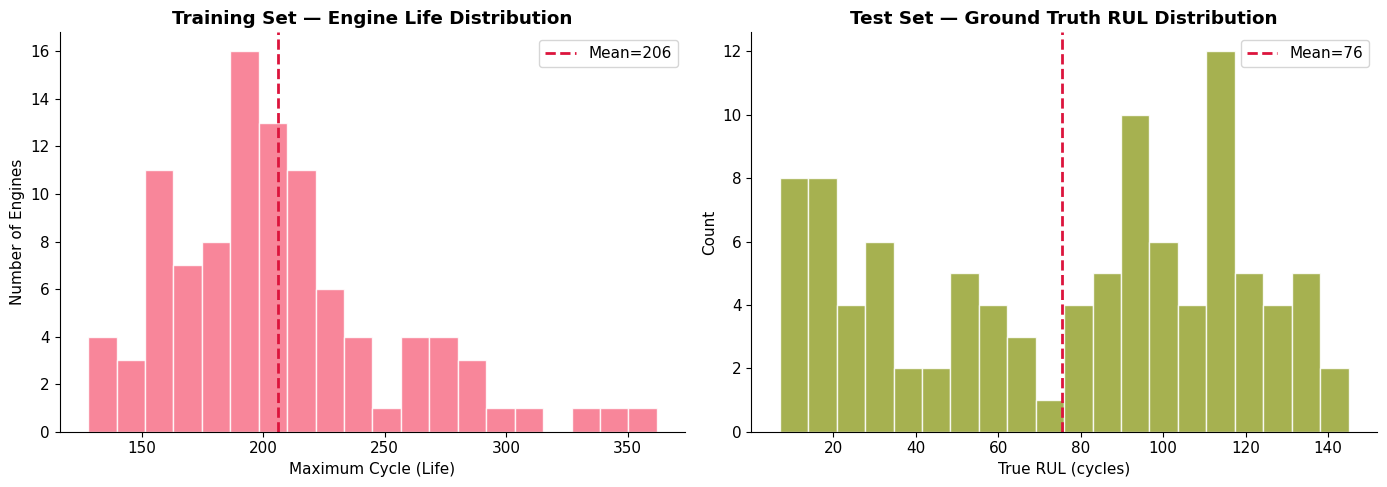

Figure saved → outputs/eda_life_distribution.png


In [6]:
# ── Engine life distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set engine lives
train_lives = train_df.groupby('unit_id')['cycle'].max()
axes[0].hist(train_lives, bins=20, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(train_lives.mean(), color='crimson', lw=2, linestyle='--', label=f'Mean={train_lives.mean():.0f}')
axes[0].set_title('Training Set — Engine Life Distribution', fontweight='bold')
axes[0].set_xlabel('Maximum Cycle (Life)')
axes[0].set_ylabel('Number of Engines')
axes[0].legend()

# Test ground-truth RUL distribution
axes[1].hist(rul_df['RUL'], bins=20, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].axvline(rul_df['RUL'].mean(), color='crimson', lw=2, linestyle='--', label=f'Mean={rul_df["RUL"].mean():.0f}')
axes[1].set_title('Test Set — Ground Truth RUL Distribution', fontweight='bold')
axes[1].set_xlabel('True RUL (cycles)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'eda_life_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → outputs/eda_life_distribution.png")

## 4. Operating Conditions Analysis

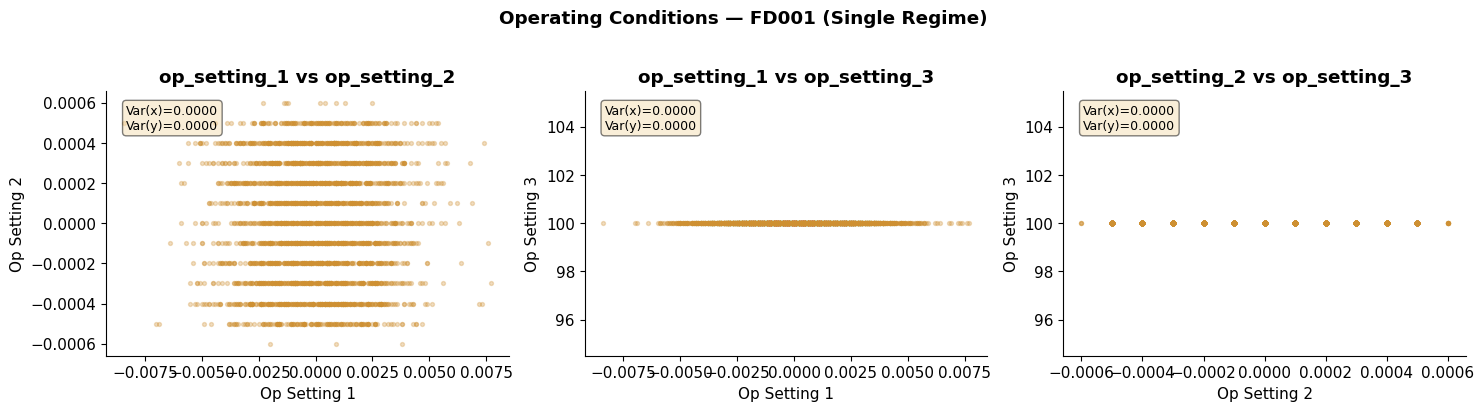

Note: FD001 has near-zero variance in op_settings → single operating regime


In [7]:
# ── Operating conditions scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

op_pairs = [
    ('op_setting_1', 'op_setting_2'),
    ('op_setting_1', 'op_setting_3'),
    ('op_setting_2', 'op_setting_3'),
]

sample = train_df.sample(min(3000, len(train_df)), random_state=42)

for ax, (x_col, y_col) in zip(axes, op_pairs):
    ax.scatter(sample[x_col], sample[y_col], alpha=0.3, s=8, color=COLORS[1])
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.set_title(f'{x_col} vs {y_col}', fontweight='bold')

    # Check variance
    var_x = sample[x_col].var()
    var_y = sample[y_col].var()
    ax.text(0.05, 0.95, f'Var(x)={var_x:.4f}\nVar(y)={var_y:.4f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Operating Conditions — FD001 (Single Regime)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'eda_operating_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: FD001 has near-zero variance in op_settings → single operating regime")

## 5. Sensor Time-Series Analysis

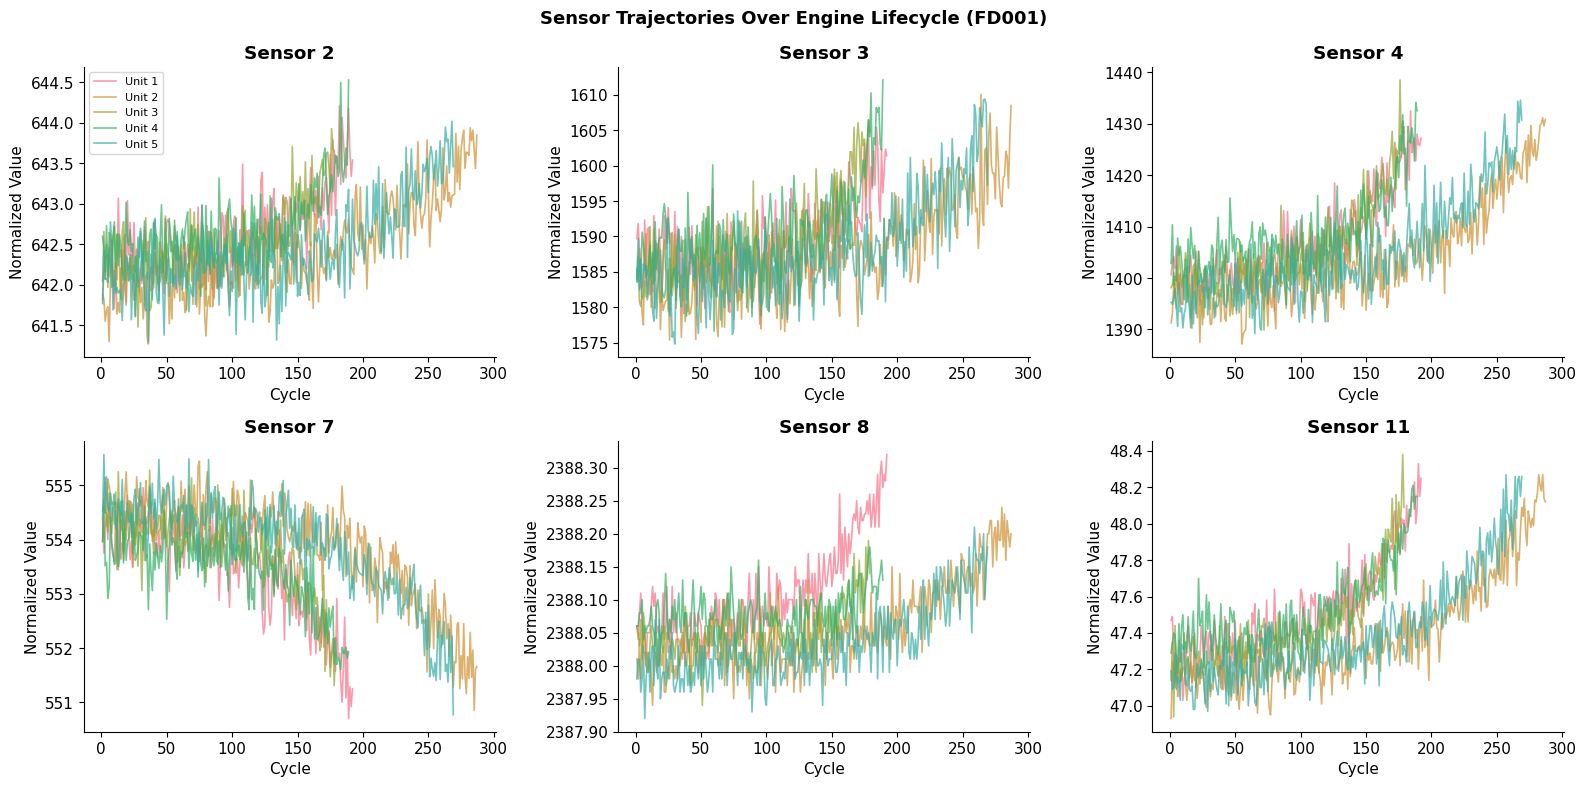

In [8]:
# ── Sensor trajectories over lifecycle ─────────────────────────────────────────
# Show 3 representative engines across their full life
SENSORS_TO_PLOT = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11']
SAMPLE_UNITS = list(train_df['unit_id'].unique()[:5])  # First 5 engines

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, sensor in zip(axes, SENSORS_TO_PLOT):
    for i, uid in enumerate(SAMPLE_UNITS):
        unit_data = train_df[train_df['unit_id'] == uid].sort_values('cycle')
        ax.plot(unit_data['cycle'], unit_data[sensor],
                alpha=0.7, lw=1.2, color=COLORS[i], label=f'Unit {uid}')
    ax.set_title(sensor.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Normalized Value')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Sensor Trajectories Over Engine Lifecycle (FD001)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'eda_sensor_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sensor Variance Analysis (Constant Sensor Identification)

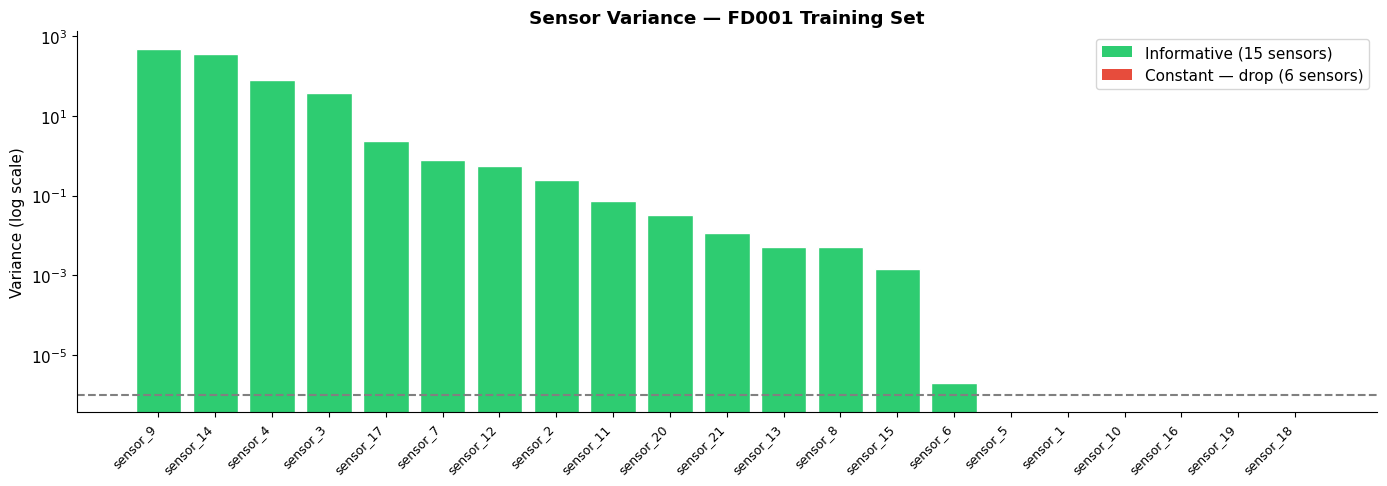

🗑  Constant sensors (will be dropped): ['sensor_5', 'sensor_1', 'sensor_10', 'sensor_16', 'sensor_19', 'sensor_18']
✅  Informative sensors (kept)        : ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17', 'sensor_7', 'sensor_12', 'sensor_2', 'sensor_11', 'sensor_20', 'sensor_21', 'sensor_13', 'sensor_8', 'sensor_15', 'sensor_6']


In [9]:
# ── Sensor variance analysis ───────────────────────────────────────────────────
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_variances = train_df[sensor_cols].var().sort_values(ascending=False)

VARIANCE_THRESHOLD = 1e-6
constant_sensors = sensor_variances[sensor_variances < VARIANCE_THRESHOLD].index.tolist()
informative_sensors = sensor_variances[sensor_variances >= VARIANCE_THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#e74c3c' if v < VARIANCE_THRESHOLD else '#2ecc71'
              for v in sensor_variances.values]
bars = ax.bar(range(len(sensor_variances)), sensor_variances.values, color=colors_bar, edgecolor='white')
ax.set_xticks(range(len(sensor_variances)))
ax.set_xticklabels(sensor_variances.index, rotation=45, ha='right', fontsize=9)
ax.axhline(VARIANCE_THRESHOLD, color='gray', linestyle='--', lw=1.5, label=f'Threshold={VARIANCE_THRESHOLD}')
ax.set_yscale('log')
ax.set_title('Sensor Variance — FD001 Training Set', fontweight='bold')
ax.set_ylabel('Variance (log scale)')
ax.legend()

# Add legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label=f'Informative ({len(informative_sensors)} sensors)'),
    Patch(facecolor='#e74c3c', label=f'Constant — drop ({len(constant_sensors)} sensors)')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'eda_sensor_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🗑  Constant sensors (will be dropped): {constant_sensors}")
print(f"✅  Informative sensors (kept)        : {informative_sensors}")

## 7. Sensor Correlation Heatmap

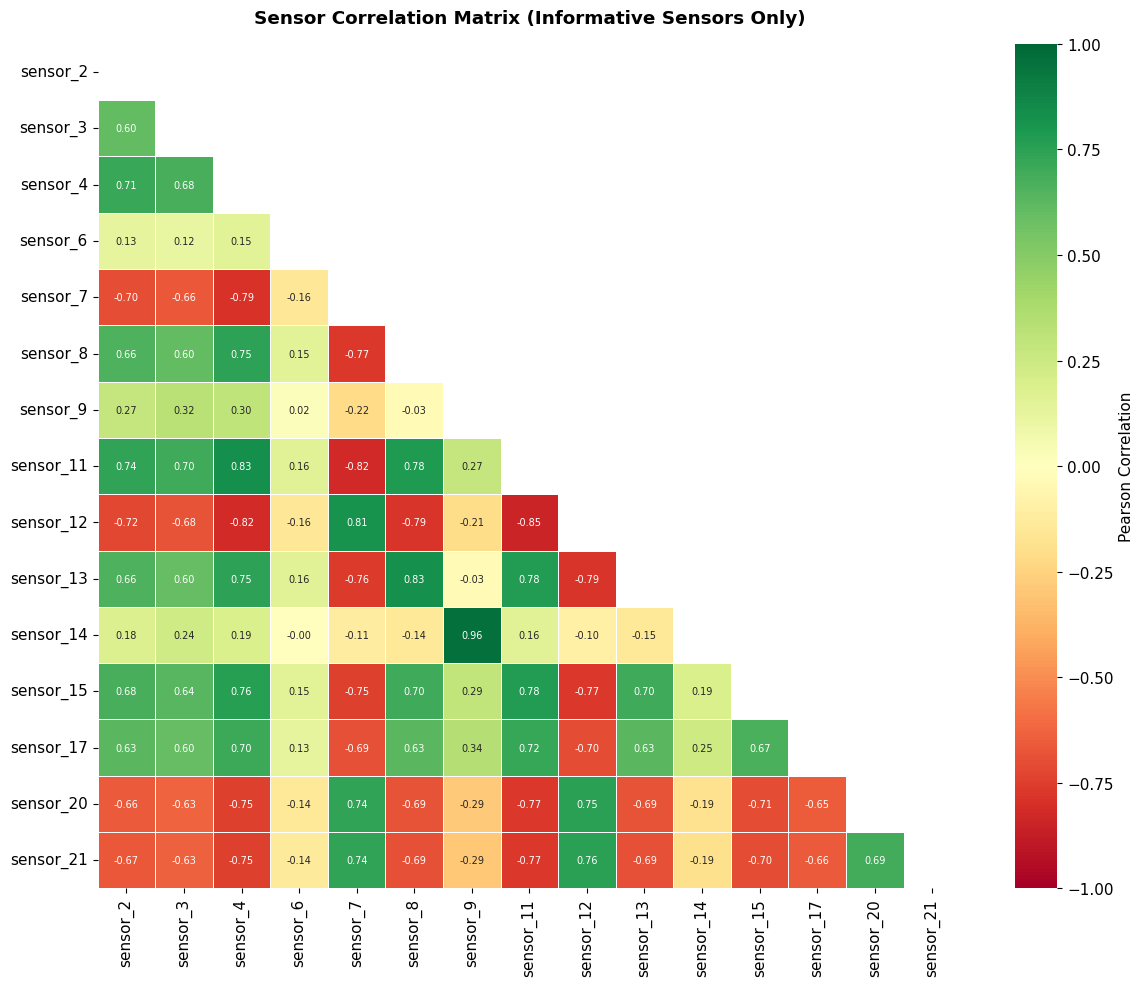

In [10]:
# ── Sensor correlation heatmap ─────────────────────────────────────────────────
# Use only informative (non-constant) sensors
active_sensors = [s for s in sensor_cols if s in informative_sensors]
corr_matrix = train_df[active_sensors].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Sensor Correlation Matrix (Informative Sensors Only)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'eda_sensor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Multi-Dataset Comparison

In [11]:
# ── Attempt to load all 4 datasets ────────────────────────────────────────────
all_datasets = loader.load_all_datasets()

summary_rows = []
for name, data in all_datasets.items():
    tr = data['train']
    te = data['test']
    rl = data['rul']
    train_units = tr['unit_id'].nunique()
    test_units = te['unit_id'].nunique()
    avg_life = tr.groupby('unit_id')['cycle'].max().mean()
    test_avg_rul = rl['RUL'].mean()
    summary_rows.append({
        'Dataset': name,
        'Train Units': train_units,
        'Train Rows': len(tr),
        'Test Units': test_units,
        'Avg Engine Life': f'{avg_life:.1f} cycles',
        'Avg Test RUL': f'{test_avg_rul:.1f} cycles',
        'Memory (MB)': f'{tr.memory_usage(deep=True).sum() / 1e6:.1f}'
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df.set_index('Dataset'))
else:
    print("ℹ️  Only synthetic FD001 available. Place all 4 dataset files in data/raw/ for full comparison.")

    # Show expected summary based on literature
    expected = pd.DataFrame([
        {'Dataset':'FD001','Train Units':100,'Train Rows':'~20,631','Test Units':100,'Avg Engine Life':'~206 cycles','Op Conditions':1,'Fault Modes':1},
        {'Dataset':'FD002','Train Units':260,'Train Rows':'~53,759','Test Units':259,'Avg Engine Life':'~206 cycles','Op Conditions':6,'Fault Modes':1},
        {'Dataset':'FD003','Train Units':100,'Train Rows':'~24,720','Test Units':100,'Avg Engine Life':'~247 cycles','Op Conditions':1,'Fault Modes':2},
        {'Dataset':'FD004','Train Units':248,'Train Rows':'~61,249','Test Units':249,'Avg Engine Life':'~247 cycles','Op Conditions':6,'Fault Modes':2},
    ])
    display(expected.set_index('Dataset'))

,Train Units,Train Rows,Test Units,Avg Engine Life,Avg Test RUL,Memory (MB)
Dataset,,,,,,
FD001,100,20631,100,206.3 cycles,75.5 cycles,2.3
FD002,260,53759,259,206.8 cycles,81.2 cycles,6.0
FD003,100,24720,100,247.2 cycles,75.3 cycles,2.8
FD004,249,61249,248,246.0 cycles,86.6 cycles,6.9


## 9. Key Findings Summary

| Finding | FD001 Value | Implication |
|---------|------------|-------------|
| Engine life range | ~100–362 cycles | Wide variance → piece-wise linear RUL capping needed |
| Constant sensors | 6 of 21 | Remove before training (no information) |
| Informative sensors | 15 of 21 | These form the model input feature set |
| Operating regimes | 1 (FD001) | No operating condition clustering needed for FD001 |
| Missing values | 0 | Clean dataset — no imputation needed |
| Memory optimization | ~50% | int32/float32 casting halves memory footprint |

---

**Next:** `02_feature_engineering.ipynb` — RUL computation, capping, clustering, and normalization pipeline.